# T/NK Cell Major Type Annotation

**Objective**: Annotate T/NK cell dataset to identify major cell types (NK cells, CD4 T, CD8 T, etc.)

**Workflow** (Following annotation_universal pattern):
- **Pre-annotation mode**: Generate marker analysis and annotation template
- **Manual annotation**: Edit Annotation.csv to assign cell types (identify NK vs T cells)
- **Post-annotation mode**: Apply annotations and visualize (run in separate session)
- **Subset**: Extract pure T cells based on annotations (for subsequent analysis)

**Current Mode**: PRE-ANNOTATION

This notebook generates marker analysis to help identify:
- NK cells (NCAM1, NKG7, GNLY, KLRD1)
- T cell subtypes (CD4, CD8, Naive, Effector, Treg, etc.)

---
## Step 1: Import Libraries

In [1]:
# Import libraries
import sys
import os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy.sparse import issparse, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Single-cell analysis
import scanpy as sc

warnings.filterwarnings('ignore')

# Check versions
print(f"scanpy: {sc.__version__}")
print(f"Python: {sys.version}")

# Plot settings
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)
plt.rcParams['figure.figsize'] = (8, 6)

print("\n✓ All libraries loaded successfully")

scanpy: 1.9.8
Python: 3.9.24 (main, Oct 21 2025, 20:11:42) 
[GCC 11.2.0]

✓ All libraries loaded successfully


---
## Step 2: Configuration

In [2]:
# ==================== Configuration ====================

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"✓ Random seed set to {RANDOM_SEED}")

# Input/Output paths
INPUT_H5AD = "/home/h2048/data/py/1203/T_scvi_integration/adata_tcell_scvi_full.h5ad"
OUTPUT_DIR = "/home/h2048/data/py/1204/TNK_major_annotation"

# Clustering resolution to use for annotation
RESOLUTION = "default"  # Options: "default" or specific number (e.g., 3.0)
# If "default": will use 'leiden' or 'leiden_bbknn' or 'leiden_scvi'
# If number: will use f'leiden_res{RESOLUTION}'

# Marker genes for T/NK cell annotation
# Following annotation_universal pattern
T_NK_MARKERS = [
    # Pan T markers
    'CD3D', 'CD3E', 'CD3G',
    # NK markers
    'NCAM1', 'NKG7', 'GNLY', 'KLRD1', 'FCGR3A',
    # CD4 T cells
    'CD4', 'IL7R',
    # CD8 T cells
    'CD8A', 'CD8B',
    # Naive markers
    'CCR7', 'SELL', 'LEF1', 'TCF7',
    # Effector/Memory markers
    'GZMA', 'GZMB', 'GZMK', 'PRF1',
    # Treg markers
    'FOXP3', 'IL2RA', 'CTLA4',
    # Activation markers
    'IFNG', 'TNF', 'IL2',
    # Exhaustion markers
    'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2',
    # Resident memory markers
    'CD69', 'ITGAE', 'CXCR6',
    # Proliferation markers
    'MKI67', 'TOP2A'
]

# Differential expression parameters
RUN_FIND_MARKERS = True
MARKER_MIN_PCT = 0.25
MARKER_LOGFC_THRESHOLD = 0.25
TOP_N_MARKERS = 10
MIN_CELLS_PER_CLUSTER = 20

# Visualization settings
GENERATE_DOTPLOT = True
GENERATE_HEATMAP = True
HEATMAP_BATCH_SIZE = 25
MAX_CELLS_PER_GROUP_PLOTTING = 300  # Subsample for heavy plots
DPI = 300
FIGURE_FORMAT = "pdf"

# Create output directories
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

fig_dir = output_dir / "figures"
fig_dir.mkdir(exist_ok=True)

print("\n✓ Configuration loaded")
print(f"  Input: {INPUT_H5AD}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Resolution: {RESOLUTION}")
print(f"  Marker genes: {len(T_NK_MARKERS)}")
print(f"\n✓ Directories created:")
print(f"  Output: {output_dir}")
print(f"  Figures: {fig_dir}")

✓ Random seed set to 42

✓ Configuration loaded
  Input: /home/h2048/data/py/1203/T_scvi_integration/adata_tcell_scvi_full.h5ad
  Output: /home/h2048/data/py/1204/TNK_major_annotation
  Resolution: default
  Marker genes: 35

✓ Directories created:
  Output: /home/h2048/data/py/1204/TNK_major_annotation
  Figures: /home/h2048/data/py/1204/TNK_major_annotation/figures


---
## Step 3: Load Data

In [3]:
print("\n" + "="*70)
print("Step 3: Loading Data")
print("="*70)

# Load data
adata = sc.read_h5ad(INPUT_H5AD)
print(f"\nLoaded: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes")

# Check data structure
print(f"\nadata.X: {type(adata.X).__name__}, sparse={issparse(adata.X)}")

# Check layers - give warnings but don't error
print(f"\nadata.layers:")
if len(adata.layers) == 0:
    print("  ⚠️  No layers found (this is acceptable)")
else:
    print(f"  Available: {list(adata.layers.keys())}")

# Check obsm
print(f"\nadata.obsm: {list(adata.obsm.keys())}")
has_umap = 'X_umap' in adata.obsm
if has_umap:
    print("  ✓ UMAP available")

print("\n✓ Data loaded successfully")


Step 3: Loading Data

Loaded: 45,676 cells × 34,252 genes

adata.X: csc_matrix, sparse=True

adata.layers:
  Available: ['counts', 'raw_counts']

adata.obsm: ['X_pca', 'X_scvi', 'X_umap']
  ✓ UMAP available

✓ Data loaded successfully


---
## Step 4: Resolve Clustering Column

In [4]:
print("\n" + "="*70)
print("Step 4: Resolving Clustering Column")
print("="*70)

def resolve_cluster_key(adata, resolution):
    """
    Resolve cluster column based on resolution.
    Following annotation_universal logic.
    """
    if resolution == "default":
        # Try common default names in order
        candidates = ['leiden', 'leiden_bbknn', 'leiden_scvi', 'clusters', 'louvain']
        for key in candidates:
            if key in adata.obs.columns:
                return key
        
        # If no default, use first leiden column
        leiden_cols = [c for c in adata.obs.columns if 'leiden' in c.lower()]
        if leiden_cols:
            return leiden_cols[0]
        
        raise ValueError(
            f"No clustering column found. Available: {adata.obs.columns.tolist()}"
        )
    else:
        # Resolution-specific
        res_str = str(resolution)
        candidates = [
            f'leiden_res{res_str}',
            f'leiden_bbknn_res{res_str}',
            f'leiden_scvi_res{res_str}'
        ]
        
        for key in candidates:
            if key in adata.obs.columns:
                return key
        
        raise ValueError(
            f"No clustering column for resolution {resolution}. "
            f"Available: {adata.obs.columns.tolist()}"
        )

# Resolve cluster key
cluster_key = resolve_cluster_key(adata, RESOLUTION)
print(f"\n✓ Using cluster column: '{cluster_key}'")

# Check cluster distribution
cluster_counts = adata.obs[cluster_key].value_counts().sort_index()
n_clusters = len(cluster_counts)

print(f"\nCluster Distribution:")
print(f"  Total clusters: {n_clusters}")
print(f"  Size range: {cluster_counts.min():,} - {cluster_counts.max():,} cells")
print(f"  Mean cluster size: {cluster_counts.mean():.0f} cells")

print(f"\n  All clusters:")
for cluster, count in cluster_counts.items():
    pct = count / len(adata) * 100
    print(f"    Cluster {cluster}: {count:,} cells ({pct:.1f}%)")

print("\n✓ Clustering resolved")


Step 4: Resolving Clustering Column

✓ Using cluster column: 'leiden'

Cluster Distribution:
  Total clusters: 48
  Size range: 55 - 2,000 cells
  Mean cluster size: 952 cells

  All clusters:
    Cluster 0: 2,000 cells (4.4%)
    Cluster 1: 1,744 cells (3.8%)
    Cluster 2: 1,679 cells (3.7%)
    Cluster 3: 1,671 cells (3.7%)
    Cluster 4: 1,622 cells (3.6%)
    Cluster 5: 1,594 cells (3.5%)
    Cluster 6: 1,529 cells (3.3%)
    Cluster 7: 1,474 cells (3.2%)
    Cluster 8: 1,464 cells (3.2%)
    Cluster 9: 1,393 cells (3.0%)
    Cluster 10: 1,298 cells (2.8%)
    Cluster 11: 1,294 cells (2.8%)
    Cluster 12: 1,271 cells (2.8%)
    Cluster 13: 1,219 cells (2.7%)
    Cluster 14: 1,216 cells (2.7%)
    Cluster 15: 1,179 cells (2.6%)
    Cluster 16: 1,127 cells (2.5%)
    Cluster 17: 1,070 cells (2.3%)
    Cluster 18: 1,063 cells (2.3%)
    Cluster 19: 1,053 cells (2.3%)
    Cluster 20: 1,049 cells (2.3%)
    Cluster 21: 1,044 cells (2.3%)
    Cluster 22: 1,030 cells (2.3%)
    Cluster

---
## Step 5: Check Marker Availability

In [5]:
print("\n" + "="*70)
print("Step 5: Checking Marker Gene Availability")
print("="*70)

# Check which markers are available
available_markers = [g for g in T_NK_MARKERS if g in adata.var_names]
missing_markers = [g for g in T_NK_MARKERS if g not in adata.var_names]

print(f"\nTotal markers requested: {len(T_NK_MARKERS)}")
print(f"Available: {len(available_markers)} ({len(available_markers)/len(T_NK_MARKERS)*100:.1f}%)")
print(f"Missing: {len(missing_markers)} ({len(missing_markers)/len(T_NK_MARKERS)*100:.1f}%)")

if len(available_markers) == 0:
    raise ValueError("No markers found in dataset!")

print(f"\nAvailable markers:")
for i in range(0, len(available_markers), 8):
    print(f"  {', '.join(available_markers[i:i+8])}")

if len(missing_markers) > 0:
    print(f"\nMissing markers:")
    for i in range(0, len(missing_markers), 8):
        print(f"  {', '.join(missing_markers[i:i+8])}")

print("\n✓ Marker check complete")


Step 5: Checking Marker Gene Availability

Total markers requested: 35
Available: 35 (100.0%)
Missing: 0 (0.0%)

Available markers:
  CD3D, CD3E, CD3G, NCAM1, NKG7, GNLY, KLRD1, FCGR3A
  CD4, IL7R, CD8A, CD8B, CCR7, SELL, LEF1, TCF7
  GZMA, GZMB, GZMK, PRF1, FOXP3, IL2RA, CTLA4, IFNG
  TNF, IL2, PDCD1, LAG3, TIGIT, HAVCR2, CD69, ITGAE
  CXCR6, MKI67, TOP2A

✓ Marker check complete


---
## Step 6: Generate Marker DotPlot


Step 6: Generating Marker DotPlot

Creating dotplot with 35 markers...


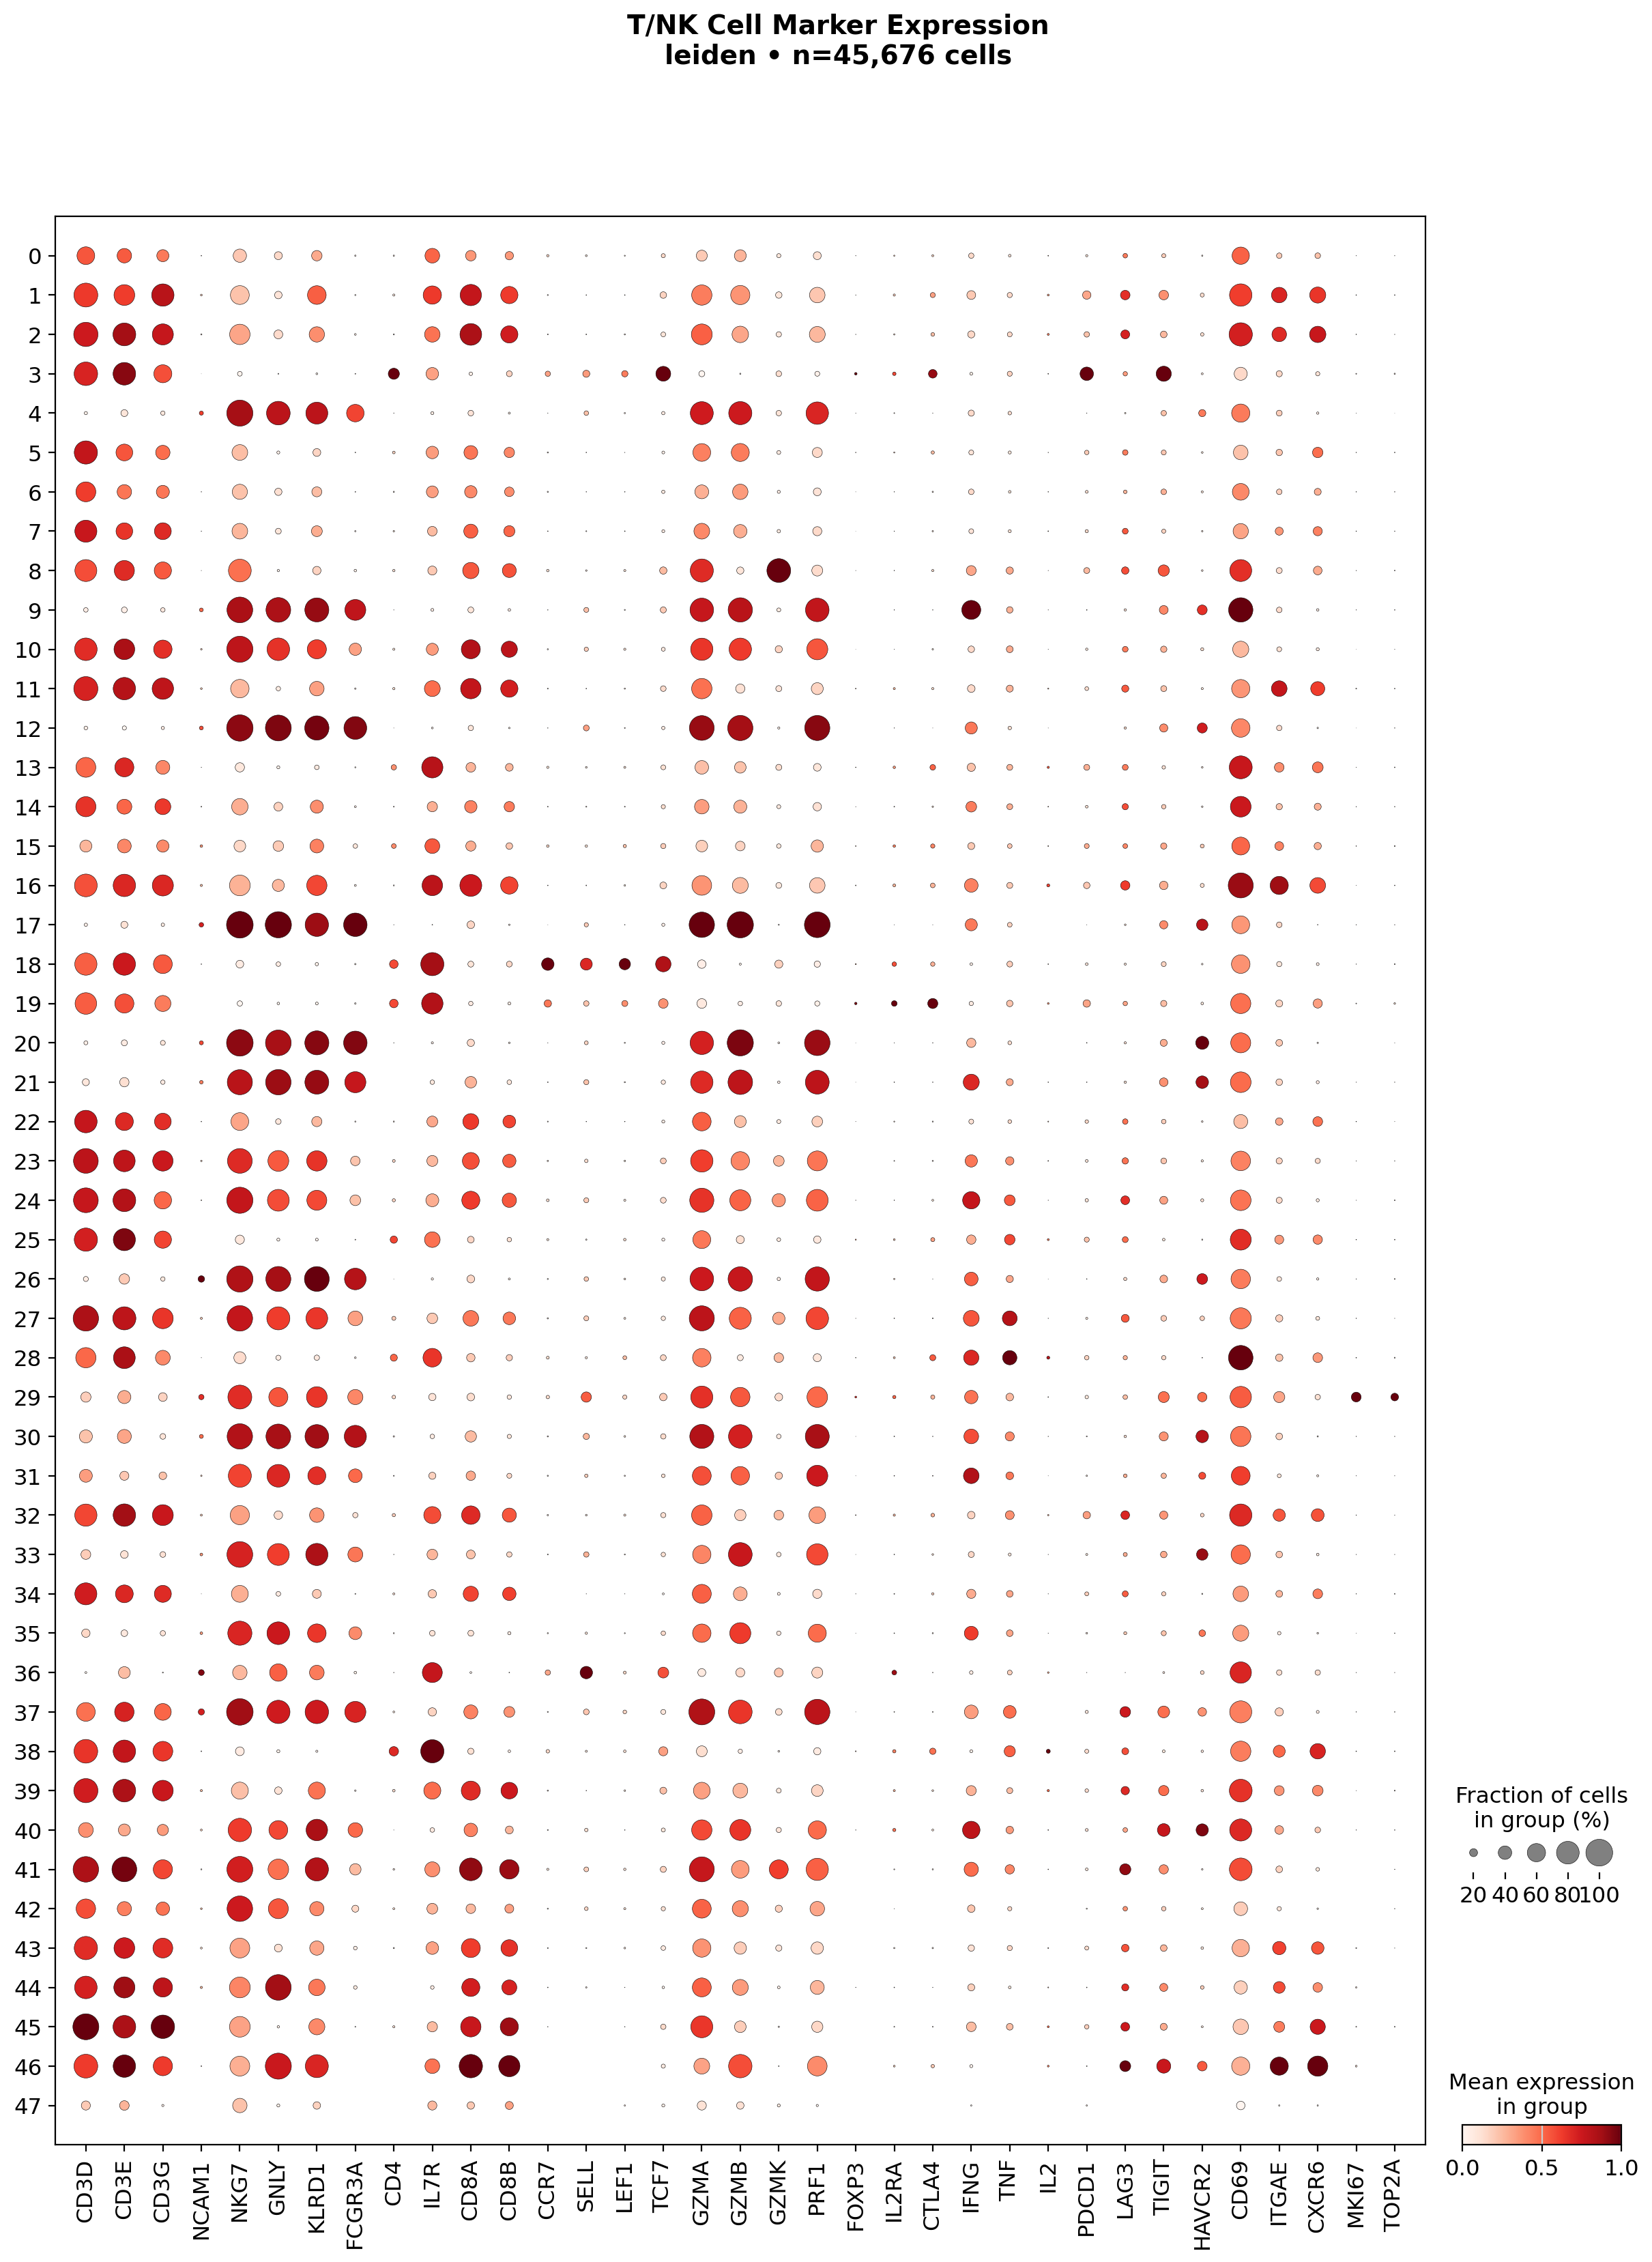


✓ Dotplot saved: /home/h2048/data/py/1204/TNK_major_annotation/figures/dotplot_TNK_markers.pdf

✓ Dotplot step complete


In [6]:
print("\n" + "="*70)
print("Step 6: Generating Marker DotPlot")
print("="*70)

if GENERATE_DOTPLOT and len(available_markers) > 0:
    print(f"\nCreating dotplot with {len(available_markers)} markers...")
    
    try:
        # Calculate figure size
        fig_width = max(12, len(available_markers) * 0.35)
        fig_height = max(6, n_clusters * 0.35)
        
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
        
        sc.pl.dotplot(
            adata,
            var_names=available_markers,
            groupby=cluster_key,
            ax=ax,
            show=False,
            standard_scale='var'
        )
        
        ax.set_title(f'T/NK Cell Marker Expression\n{cluster_key} • n={len(adata):,} cells',
                    fontsize=14, fontweight='bold', pad=20)
        
        plt.tight_layout()
        output_file = fig_dir / f'dotplot_TNK_markers.{FIGURE_FORMAT}'
        plt.savefig(output_file, dpi=DPI, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ Dotplot saved: {output_file}")
        
    except Exception as e:
        print(f"\n⚠️  Failed to generate dotplot: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n  Skipping dotplot generation")

print("\n✓ Dotplot step complete")

---
## Step 7: Find Cluster Markers (Differential Expression)

In [7]:
print("\n" + "="*70)
print("Step 7: Finding Cluster Marker Genes")
print("="*70)

marker_df = None

if RUN_FIND_MARKERS:
    print(f"\nDifferential expression parameters:")
    print(f"  Method: Wilcoxon rank-sum test")
    print(f"  Cluster key: {cluster_key}")
    print(f"  min_pct: {MARKER_MIN_PCT}")
    print(f"  logfc_threshold: {MARKER_LOGFC_THRESHOLD}")
    print(f"  min_cells_per_cluster: {MIN_CELLS_PER_CLUSTER}")
    
    try:
        # Filter clusters with too few cells
        valid_clusters = cluster_counts[cluster_counts >= MIN_CELLS_PER_CLUSTER].index
        excluded_clusters = set(cluster_counts.index) - set(valid_clusters)
        
        if len(excluded_clusters) > 0:
            print(f"\n⚠️  Excluding {len(excluded_clusters)} small clusters:")
            for cl in sorted(excluded_clusters):
                print(f"  Cluster {cl}: {cluster_counts[cl]} cells (< {MIN_CELLS_PER_CLUSTER})")
        
        if len(valid_clusters) == 0:
            print(f"\n⚠️  No clusters pass threshold")
            print(f"  Consider lowering min_cells_per_cluster")
        else:
            # Create filtered dataset for DE
            adata_de = adata[adata.obs[cluster_key].isin(valid_clusters)].copy()
            
            print(f"\nProceeding with {len(valid_clusters)} clusters")
            print(f"  Total cells: {len(adata_de):,}")
            
            # Run differential expression
            print(f"\nRunning Wilcoxon test...")
            print(f"  (This may take several minutes for large datasets)")
            
            sc.tl.rank_genes_groups(
                adata_de,
                groupby=cluster_key,
                method='wilcoxon',
                pts=True
            )
            
            print(f"  ✓ Analysis complete")
            
            # Extract results
            print(f"\nExtracting marker genes...")
            
            result = adata_de.uns['rank_genes_groups']
            groups = result['names'].dtype.names
            
            marker_records = []
            for group in groups:
                for idx in range(len(result['names'][group])):
                    marker_records.append({
                        'cluster': group,
                        'gene': result['names'][group][idx],
                        'avg_log2FC': result['logfoldchanges'][group][idx],
                        'pvals': result['pvals'][group][idx],
                        'pvals_adj': result['pvals_adj'][group][idx],
                        'pct.1': result['pts'][group][idx] if 'pts' in result else np.nan,
                        'pct.2': result['pts_rest'][group][idx] if 'pts_rest' in result else np.nan
                    })
            
            marker_df = pd.DataFrame(marker_records)
            
            # Apply thresholds
            marker_df_filtered = marker_df[
                (marker_df['pct.1'] >= MARKER_MIN_PCT) &
                (marker_df['avg_log2FC'].abs() >= MARKER_LOGFC_THRESHOLD)
            ].copy()
            
            if len(marker_df_filtered) > 0:
                # Save to file
                output_file = output_dir / 'cluster_markers.csv'
                marker_df_filtered.to_csv(output_file, index=False, encoding='utf-8')
                
                print(f"\n✓ Marker genes saved: {output_file}")
                print(f"  Total markers: {len(marker_df_filtered):,}")
                print(f"  Clusters with markers: {marker_df_filtered['cluster'].nunique()}")
                
                # Display top markers per cluster
                print(f"\nTop 5 markers per cluster:")
                for cluster in sorted(marker_df_filtered['cluster'].unique(), key=lambda x: str(x)):
                    top_markers = (
                        marker_df_filtered[marker_df_filtered['cluster'] == cluster]
                        .sort_values('avg_log2FC', ascending=False)
                        .head(5)
                    )
                    genes = ', '.join(top_markers['gene'].values)
                    print(f"  Cluster {cluster}: {genes}")
                
                marker_df = marker_df_filtered
            else:
                print(f"\n⚠️  No significant markers after thresholding")
                marker_df = None
    
    except Exception as e:
        print(f"\n⚠️  DE analysis failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n  Skipping DE analysis")

print("\n✓ Marker gene analysis complete")


Step 7: Finding Cluster Marker Genes

Differential expression parameters:
  Method: Wilcoxon rank-sum test
  Cluster key: leiden
  min_pct: 0.25
  logfc_threshold: 0.25
  min_cells_per_cluster: 20

Proceeding with 48 clusters
  Total cells: 45,676

Running Wilcoxon test...
  (This may take several minutes for large datasets)
ranking genes
    finished (0:09:17)
  ✓ Analysis complete

Extracting marker genes...

✓ Marker genes saved: /home/h2048/data/py/1204/TNK_major_annotation/cluster_markers.csv
  Total markers: 40,447
  Clusters with markers: 48

Top 5 markers per cluster:
  Cluster 0: CTA-384D8.28, AC025198.1, RP4-753P9.3, KIAA0114, RP13-122B23.13
  Cluster 1: IRF1-AS1, ITPRID1, MIR1244-2, AL049712.1, LINC01090
  Cluster 10: AL158801.5, AC025580.1, BX679664.3, RP11-66D17.5, CTD-2337A12.1
  Cluster 11: C4B, LINC01206, ADGRL3-AS1, LINC02774, LOC107985579
  Cluster 12: COL20A1, AL008638.3, AGAP11, RP11-322E11.6, SMPX
  Cluster 13: NIFKP6, CTD-3137H5.1, AL591468.2, AL121721.1, RN7SL36

---
## Step 8: Generate Marker Heatmaps


Step 8: Generating Marker Gene Heatmaps

Selecting top 10 markers per cluster...
  Total unique markers: 470

Preparing data for heatmap...
  Subsampling to 300 cells per cluster...
  Using 13,820 cells for visualization

Generating 19 heatmap(s)...
  Batch 1/19: 25 genes
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`

⚠️  Heatmap generation failed: inner() got multiple values for argument 'ax'

✓ Heatmap step complete


Traceback (most recent call last):
  File "/tmp/ipykernel_1291856/4142433634.py", line 54, in <module>
    sc.pl.heatmap(
  File "/home/h2048/miniconda3/envs/bbknn_env/lib/python3.9/site-packages/scanpy/plotting/_anndata.py", line 1177, in heatmap
    im = heatmap_ax.imshow(obs_tidy.values, aspect='auto', norm=norm, **kwds)
TypeError: inner() got multiple values for argument 'ax'


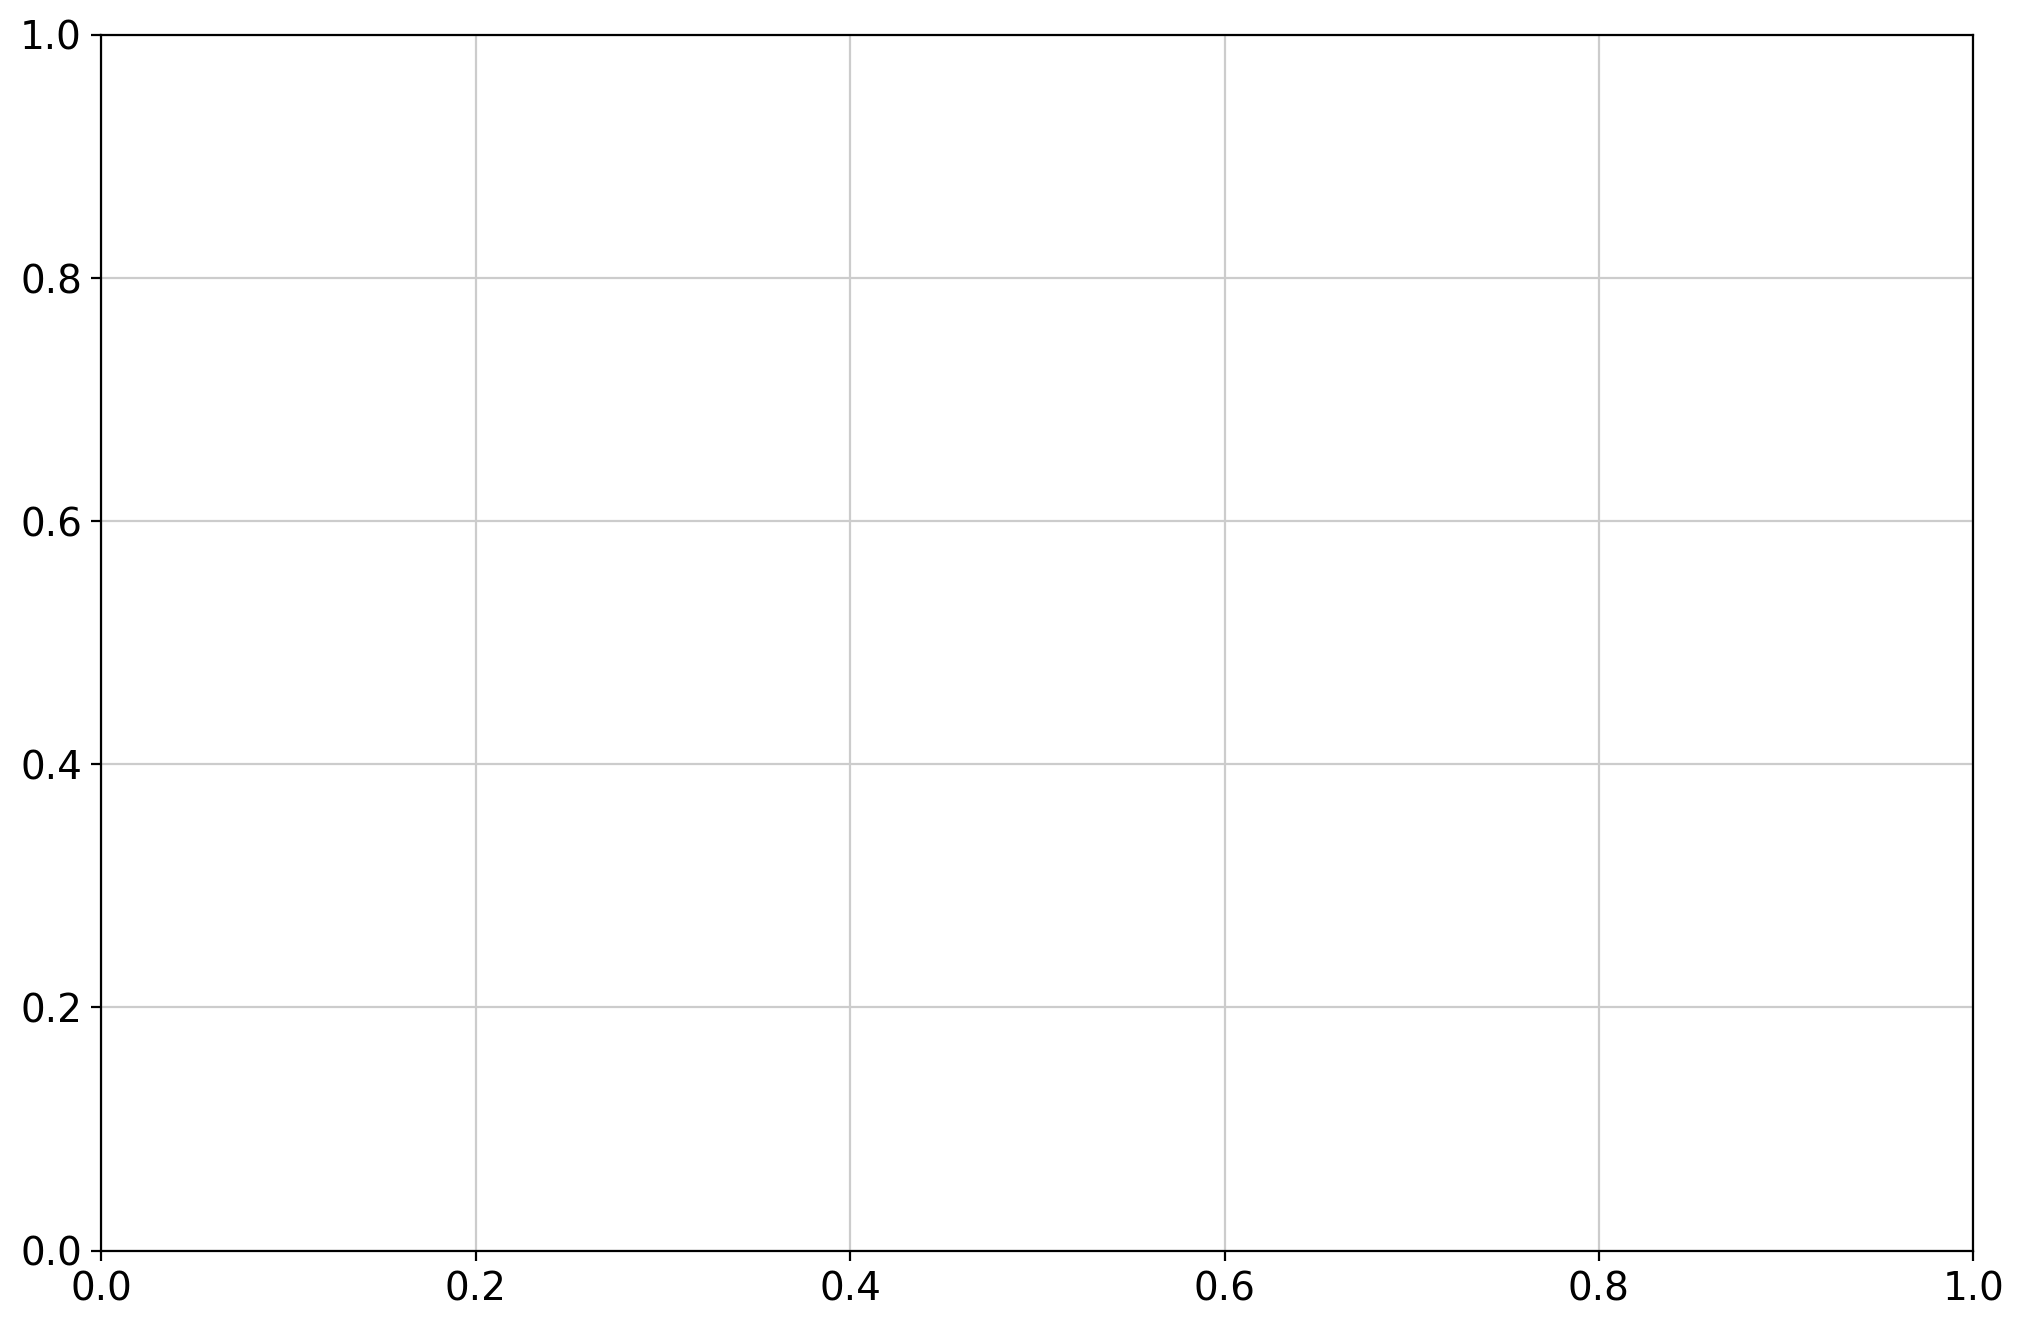

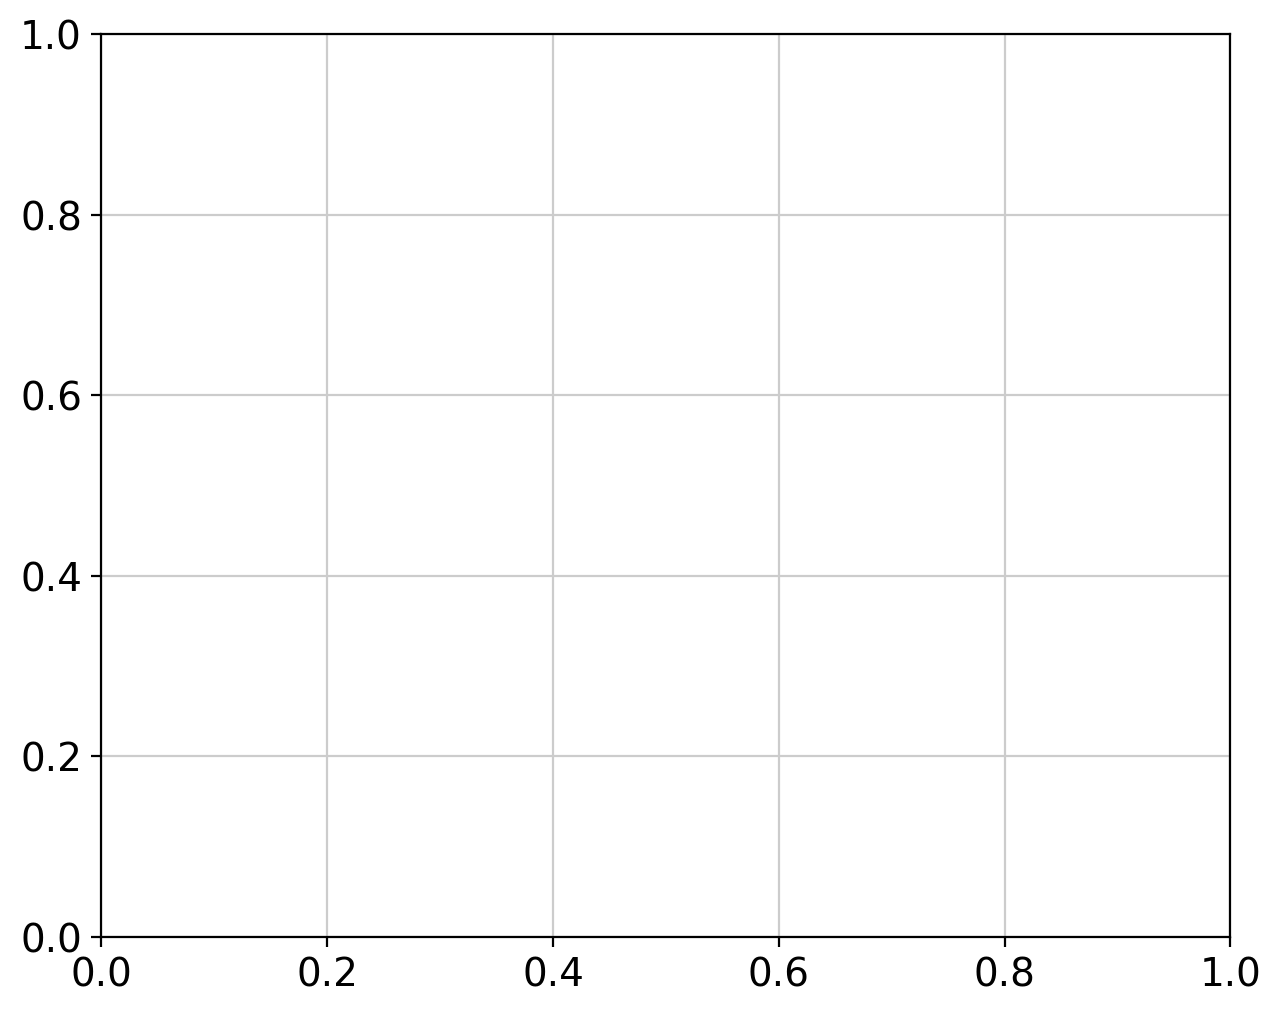

In [8]:
print("\n" + "="*70)
print("Step 8: Generating Marker Gene Heatmaps")
print("="*70)

if GENERATE_HEATMAP and marker_df is not None and len(marker_df) > 0:
    print(f"\nSelecting top {TOP_N_MARKERS} markers per cluster...")
    
    try:
        # Select top markers
        top_markers = (
            marker_df.sort_values('avg_log2FC', ascending=False)
            .groupby('cluster')
            .head(TOP_N_MARKERS)
        )
        
        top_marker_genes = top_markers['gene'].unique().tolist()
        print(f"  Total unique markers: {len(top_marker_genes)}")
        
        if len(top_marker_genes) > 0:
            # Subsample cells for plotting if needed
            print(f"\nPreparing data for heatmap...")
            if len(adata) > n_clusters * MAX_CELLS_PER_GROUP_PLOTTING:
                print(f"  Subsampling to {MAX_CELLS_PER_GROUP_PLOTTING} cells per cluster...")
                
                # Balanced subsample
                subset_indices = []
                for cluster in adata.obs[cluster_key].unique():
                    cluster_cells = adata.obs[adata.obs[cluster_key] == cluster].index
                    n_sample = min(MAX_CELLS_PER_GROUP_PLOTTING, len(cluster_cells))
                    sampled = np.random.choice(cluster_cells, n_sample, replace=False)
                    subset_indices.extend(sampled)
                
                adata_plot = adata[subset_indices].copy()
                print(f"  Using {len(adata_plot):,} cells for visualization")
            else:
                adata_plot = adata
            
            # Split into batches
            n_batches = int(np.ceil(len(top_marker_genes) / HEATMAP_BATCH_SIZE))
            print(f"\nGenerating {n_batches} heatmap(s)...")
            
            for batch_idx in range(n_batches):
                start_idx = batch_idx * HEATMAP_BATCH_SIZE
                end_idx = min((batch_idx + 1) * HEATMAP_BATCH_SIZE, len(top_marker_genes))
                batch_genes = top_marker_genes[start_idx:end_idx]
                
                if len(batch_genes) == 0:
                    continue
                
                print(f"  Batch {batch_idx + 1}/{n_batches}: {len(batch_genes)} genes")
                
                fig, ax = plt.subplots(figsize=(12, max(8, len(batch_genes) * 0.3)))
                
                sc.pl.heatmap(
                    adata_plot,
                    var_names=batch_genes,
                    groupby=cluster_key,
                    ax=ax,
                    show=False,
                    cmap='RdBu_r',
                    standard_scale='var',
                    dendrogram=True
                )
                
                ax.set_title(
                    f'Top Marker Genes • T/NK cells • {cluster_key}\n'
                    f'Batch {batch_idx + 1}/{n_batches} • n={len(adata_plot):,} cells',
                    fontsize=14, fontweight='bold'
                )
                
                output_file = fig_dir / f'heatmap_markers_batch{batch_idx + 1}.{FIGURE_FORMAT}'
                plt.savefig(output_file, dpi=DPI, bbox_inches='tight')
                plt.show()
                plt.close()
            
            print(f"\n✓ Heatmaps saved: {fig_dir}")
        else:
            print(f"  ⚠️  No genes to plot")
    
    except Exception as e:
        print(f"\n⚠️  Heatmap generation failed: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n  Skipping heatmap generation")

print("\n✓ Heatmap step complete")

---
## Step 9: Create Annotation Template

In [9]:
print("\n" + "="*70)
print("Step 9: Creating Annotation Template")
print("="*70)

# Get unique clusters and sort
clusters = sorted(adata.obs[cluster_key].unique(), key=lambda x: str(x))

# Create template DataFrame
template_df = pd.DataFrame({
    'Cluster': clusters,
    'CellType': ['Unknown'] * len(clusters)
})

# Save template WITHOUT header (annotation_universal standard)
template_file = output_dir / "Annotation_template.csv"
template_df.to_csv(template_file, index=False, header=False, encoding='utf-8')

print(f"\n✓ Annotation template created: {template_file}")
print(f"  Number of clusters: {len(clusters)}")
print(f"  Format: Cluster,CellType (NO header)")

# Create cluster reference with sizes and key marker expression
cluster_info_records = []
for cluster in clusters:
    cluster_cells = adata.obs[cluster_key] == cluster
    n_cells = cluster_cells.sum()
    pct = n_cells / len(adata) * 100
    
    # Check key marker expression
    key_markers = {
        'CD3D': 'CD3D' in adata.var_names,
        'NCAM1': 'NCAM1' in adata.var_names,
        'NKG7': 'NKG7' in adata.var_names
    }
    
    marker_expr = {}
    for marker, available in key_markers.items():
        if available:
            expr = adata[cluster_cells, marker].X.mean()
            marker_expr[f'{marker}_mean'] = expr
    
    cluster_info_records.append({
        'Cluster': cluster,
        'n_cells': n_cells,
        'percentage': pct,
        **marker_expr
    })

cluster_info_df = pd.DataFrame(cluster_info_records)
reference_file = output_dir / "cluster_info.csv"
cluster_info_df.to_csv(reference_file, index=False, encoding='utf-8')

print(f"\n✓ Cluster reference saved: {reference_file}")
print(f"  (includes cell counts and key marker expression)")

# Display cluster info
print(f"\nCluster summary:")
for _, row in cluster_info_df.iterrows():
    marker_info = []
    if 'CD3D_mean' in row:
        marker_info.append(f"CD3D={row['CD3D_mean']:.2f}")
    if 'NCAM1_mean' in row:
        marker_info.append(f"NCAM1={row['NCAM1_mean']:.2f}")
    if 'NKG7_mean' in row:
        marker_info.append(f"NKG7={row['NKG7_mean']:.2f}")
    
    marker_str = ', '.join(marker_info) if marker_info else 'no key markers'
    print(f"  Cluster {row['Cluster']}: {int(row['n_cells']):,} cells ({row['percentage']:.1f}%) | {marker_str}")

print("\n✓ Annotation template complete")


Step 9: Creating Annotation Template

✓ Annotation template created: /home/h2048/data/py/1204/TNK_major_annotation/Annotation_template.csv
  Number of clusters: 48
  Format: Cluster,CellType (NO header)

✓ Cluster reference saved: /home/h2048/data/py/1204/TNK_major_annotation/cluster_info.csv
  (includes cell counts and key marker expression)

Cluster summary:
  Cluster 0: 2,000 cells (4.4%) | CD3D=1.62, NCAM1=0.02, NKG7=1.08
  Cluster 1: 1,744 cells (3.8%) | CD3D=1.85, NCAM1=0.04, NKG7=1.15
  Cluster 10: 1,298 cells (2.8%) | CD3D=1.99, NCAM1=0.04, NKG7=3.49
  Cluster 11: 1,294 cells (2.8%) | CD3D=2.08, NCAM1=0.05, NKG7=1.27
  Cluster 12: 1,271 cells (2.8%) | CD3D=0.17, NCAM1=0.14, NKG7=4.02
  Cluster 13: 1,219 cells (2.7%) | CD3D=1.51, NCAM1=0.00, NKG7=0.55
  Cluster 14: 1,216 cells (2.7%) | CD3D=1.92, NCAM1=0.02, NKG7=1.42
  Cluster 15: 1,179 cells (2.6%) | CD3D=0.81, NCAM1=0.09, NKG7=0.86
  Cluster 16: 1,127 cells (2.5%) | CD3D=1.67, NCAM1=0.06, NKG7=1.38
  Cluster 17: 1,070 cells 

---
## Step 10: Summary and Next Steps

In [10]:
print("\n" + "="*70)
print("PRE-ANNOTATION SUMMARY")
print("="*70)

print(f"\nCompleted: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\nDataset:")
print(f"  Cells: {len(adata):,}")
print(f"  Genes: {adata.shape[1]:,}")
print(f"  Clustering: {cluster_key}")
print(f"  Clusters: {n_clusters}")

print(f"\nMarker Analysis:")
print(f"  Markers available: {len(available_markers)}/{len(T_NK_MARKERS)}")
if marker_df is not None:
    print(f"  Significant markers: {len(marker_df):,}")
    print(f"  Clusters with markers: {marker_df['cluster'].nunique()}")

print(f"\nOutput Files:")
print(f"  Annotation template: {template_file}")
print(f"  Cluster reference: {reference_file}")
if marker_df is not None:
    print(f"  Marker genes: {output_dir}/cluster_markers.csv")
print(f"  Figures: {fig_dir}/*.{FIGURE_FORMAT}")

print("\n" + "="*70)
print("✓ PRE-ANNOTATION COMPLETE")
print("="*70)

print(f"\n📋 NEXT STEPS:")
print(f"\n1. Review analysis outputs:")
print(f"   • DotPlot: {fig_dir}/dotplot_TNK_markers.{FIGURE_FORMAT}")
print(f"   • Heatmaps: {fig_dir}/heatmap_markers_*.{FIGURE_FORMAT}")
print(f"   • Markers: {output_dir}/cluster_markers.csv")
print(f"   • Cluster info: {reference_file}")

print(f"\n2. Create annotation file:")
print(f"   cp {template_file} {output_dir}/Annotation.csv")

print(f"\n3. Edit Annotation.csv to assign cell types:")
print(f"   Format: Cluster,CellType (NO header)")
print(f"\n   Example annotations:")
print(f"   0,CD4_Naive")
print(f"   1,CD8_Effector")
print(f"   2,NK")
print(f"   3,CD4_Memory")
print(f"   4,Treg")
print(f"   ...")

print(f"\n   💡 Tips for annotation:")
print(f"   • High CD3D/CD3E/CD3G = T cells")
print(f"   • High NCAM1/NKG7/GNLY = NK cells")
print(f"   • High CD4 + low CD8A = CD4+ T cells")
print(f"   • High CD8A + low CD4 = CD8+ T cells")
print(f"   • High CCR7/SELL = Naive")
print(f"   • High GZMA/GZMB = Effector")
print(f"   • High FOXP3/IL2RA = Treg")
print(f"   • High MKI67/TOP2A = Proliferating")

print(f"\n4. After manual annotation:")
print(f"   • Run POST-ANNOTATION notebook to:")
print(f"     - Apply cell type labels")
print(f"     - Generate cell type visualizations")
print(f"     - Save annotated dataset")

print(f"\n5. Subset pure T cells:")
print(f"   • Filter out NK cells based on annotations")
print(f"   • Prepare for scVI re-integration")

print("\n" + "="*70)
print("Happy annotating! 🔬")
print("="*70)


PRE-ANNOTATION SUMMARY

Completed: 2025-12-04 10:05:36

Dataset:
  Cells: 45,676
  Genes: 34,252
  Clustering: leiden
  Clusters: 48

Marker Analysis:
  Markers available: 35/35
  Significant markers: 40,447
  Clusters with markers: 48

Output Files:
  Annotation template: /home/h2048/data/py/1204/TNK_major_annotation/Annotation_template.csv
  Cluster reference: /home/h2048/data/py/1204/TNK_major_annotation/cluster_info.csv
  Marker genes: /home/h2048/data/py/1204/TNK_major_annotation/cluster_markers.csv
  Figures: /home/h2048/data/py/1204/TNK_major_annotation/figures/*.pdf

✓ PRE-ANNOTATION COMPLETE

📋 NEXT STEPS:

1. Review analysis outputs:
   • DotPlot: /home/h2048/data/py/1204/TNK_major_annotation/figures/dotplot_TNK_markers.pdf
   • Heatmaps: /home/h2048/data/py/1204/TNK_major_annotation/figures/heatmap_markers_*.pdf
   • Markers: /home/h2048/data/py/1204/TNK_major_annotation/cluster_markers.csv
   • Cluster info: /home/h2048/data/py/1204/TNK_major_annotation/cluster_info.csv

2